# Assignment 4 - PTEN regions and sensitivity

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading the variant scores, the reference protein sequence, and the region annotations
scores = pd.read_csv("data/mavedb-00000013-a-1-scores.csv")
lines = open("data/pten-reference-protein.fasta").read().split()
ref_seq = "".join(l for l in lines if not l.startswith(">"))
regions = pd.read_csv("data/pten-region-annotations.csv")

# site needs 5 variants to be included
minimum_variants = 5
# variant needs to have been measured in at least 2 experiments
minimum_experiments = 2

# 3-letter amino-acid code -> 1-letter code
letter = {"Ala":"A","Arg":"R","Asn":"N","Asp":"D","Cys":"C","Gln":"Q","Glu":"E","Gly":"G","His":"H","Ile":"I",
          "Leu":"L","Lys":"K","Met":"M","Phe":"F","Pro":"P","Ser":"S","Thr":"T","Trp":"W","Tyr":"Y","Val":"V"}

regions

,region,start,end,source,annotation
0,phosphatase_domain,14,185,UniProt P60484,Phosphatase tensin-type domain
1,c2_domain,190,350,UniProt P60484,C2 tensin-type domain
2,disordered_tail,352,403,UniProt P60484,Disordered region


## Get the checked missense variants

In [ ]:
# data cleaning
def get_checked_missense(scores, ref_seq):
    # removing WT row because we only need variants
    df = scores[scores["hgvs_pro"] != "_wt"].copy()

    # split "p.Leu25Pro" into wt="Leu", pos=25, mut="Pro"
    parts = df["hgvs_pro"].str.extract(r"^p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|=)$")
    if parts.isna().any(axis=None):
        raise ValueError("unparseable labels: " + str(df.loc[parts.isna().any(axis=1), "hgvs_pro"].tolist()[:5]))
    df["wt"], df["pos"], df["mut"] = parts[0], parts[1].astype(int), parts[2]

    # keeping only the missense variants
    df = df[df["mut"].isin(letter) & (df["mut"] != df["wt"])]

    # making sure the position is acutally in PTEN
    if not df["pos"].between(1, len(ref_seq)).all():
        raise ValueError("positions outside protein")
    # making sure the original amino acid is correct
    if (df["wt"].map(letter) != df["pos"].map(lambda p: ref_seq[p - 1])).any():
        raise ValueError("WT residue does not match reference")
    # checking for duplicates
    if df["hgvs_pro"].duplicated().any():
        raise ValueError("duplicate variants")

    # making sure score and experiment count are numeric
    df["score"] = pd.to_numeric(df["score"], errors="raise")
    df["expts"] = pd.to_numeric(df["expts"], errors="raise")
    return df[["hgvs_pro", "wt", "pos", "mut", "score", "expts"]]

missense = get_checked_missense(scores, ref_seq)
print("checked missense variants:", len(missense))

checked missense variants: 4112


## Assign each variant a region

In [ ]:
# assigning every variant to a PTEN region based on the annotations 
def region_of(pos):
    for _, r in regions.iterrows():
        if r["start"] <= pos <= r["end"]:
            return r["region"]
    return "unannotated"

# creating a lookup table for every amino-acid position in PTEN
site_region = pd.Series({p: region_of(p) for p in range(1, len(ref_seq) + 1)})
# adding the region information to the variant
missense["region"] = missense["pos"].map(site_region)

region_order = list(regions["region"]) + ["unannotated"]
missense["region"].value_counts().reindex(region_order)

region
phosphatase_domain    1829
c2_domain             1563
disordered_tail        533
unannotated            187
Name: count, dtype: int64

## Summarize and compute medians per region

In [ ]:
def region_summary(missense, minimum_variants, minimum_experiments):
    # filtering variants by number of experiments
    v = missense[missense["score"].notna() & (missense["expts"] >= minimum_experiments)]

    # filtering sites based on number of variants
    per_site = v.groupby("pos").size()
    kept_sites = per_site[per_site >= minimum_variants].index
    # include minimum_variants required for a site
    v = v[v["pos"].isin(kept_sites)]

    # median of ALL variant scores
    site_medians = v.groupby("pos")["score"].median().to_frame("site_median")
    # median of the site medians
    site_medians["region"] = site_medians.index.map(site_region)

    # outputing DF
    out = pd.DataFrame({
        # How many variants survived the filters in this region?
        "included_variants": v.groupby("region").size(),
        # How many amino-acid positions had enough variants to survive the site filter?
        "included_sites": site_medians.groupby("region").size(),
        # How many amino-acid positions belong to each region according to the supplied annotation?
        "total_sites": site_region.value_counts(),
        "variant_median": v.groupby("region")["score"].median(),
        "site_median": site_medians.groupby("region")["site_median"].median(),
    }).reindex(region_order)
    out[["included_variants", "included_sites"]] = out[["included_variants", "included_sites"]].fillna(0).astype(int)
    return out, v, site_medians

summary, included, site_medians = region_summary(missense, minimum_variants, minimum_experiments)
summary.round(3)

,included_variants,included_sites,total_sites,variant_median,site_median
phosphatase_domain,1803,142,172,0.719,0.722
c2_domain,1502,120,161,0.731,0.752
disordered_tail,521,41,52,0.923,0.942
unannotated,179,14,18,0.922,0.910


## Visualize score statistics by region

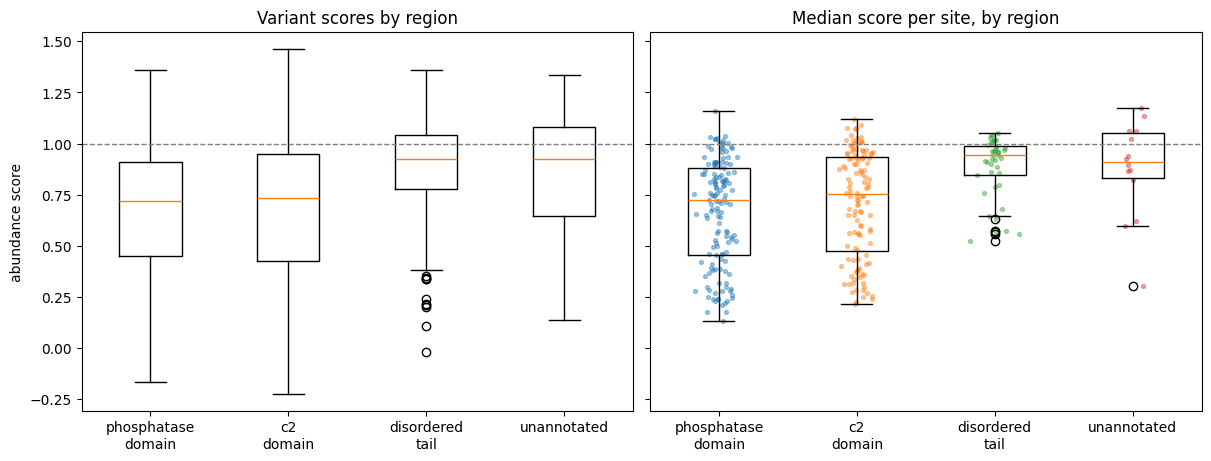

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, layout="constrained")
labels = [r.replace("_", "\n") for r in region_order]

# Distribution of individual variant scores within each region.
axes[0].boxplot([included.loc[included["region"] == r, "score"] for r in region_order], tick_labels=labels)
axes[0].set_title("Variant scores by region")
axes[0].set_ylabel("abundance score")

# Distribution of site-level median scores within each region.
axes[1].boxplot([site_medians.loc[site_medians["region"] == r, "site_median"] for r in region_order], tick_labels=labels)
for i, r in enumerate(region_order, start=1):
    y = site_medians.loc[site_medians["region"] == r, "site_median"]
    axes[1].scatter(np.random.normal(i, 0.06, len(y)), y, s=8, alpha=0.4)
axes[1].set_title("Median score per site, by region")

for ax in axes:
    ax.axhline(1, ls="--", color="gray", lw=1)
plt.show()

## Sensitivity: change the filters and see what moves

In [ ]:
rows = []
for mv in [1, 3, 5, 8, 10]:     # minimum_variants per site
    for me in [2, 4, 6, 8]:     # minimum_experiments per variant
        s, _, _ = region_summary(missense, mv, me)
        s = s.assign(minimum_variants=mv, minimum_experiments=me)
        rows.append(s.reset_index(names="region"))
sens = pd.concat(rows, ignore_index=True)

# site-median by region for every setting (rows = settings, columns = regions)
sens.pivot_table(index=["minimum_experiments", "minimum_variants"], columns="region",
                 values="site_median")[region_order].round(3)

region                                phosphatase_domain  c2_domain  \
minimum_experiments minimum_variants                                  
2                   1                              0.720      0.785   
                    3                              0.720      0.786   
                    5                              0.722      0.752   
                    8                              0.748      0.723   
                    10                             0.749      0.716   
4                   1                              0.721      0.795   
                    3                              0.725      0.775   
                    5                              0.740      0.745   
                    8                              0.728      0.732   
                    10                             0.727      0.710   
6                   1                              0.704      0.768   
                    3                              0.727      0.735   
                    5                              0.733      0.723   
                    8                              0.730      0.778   
                    10                             0.730      0.672   
8                   1                              0.722      0.731   
                    3                              0.722      0.663   
                    5                              0.735      0.775   
                    8                              0.822      0.480   
                    10                             0.832      0.306   

region                                disordered_tail  unannotated  
minimum_experiments minimum_variants                                
2                   1                           0.936        0.937  
                    3                           0.939        0.929  
                    5                           0.942        0.910  
                    8                           0.942        0.885  
                    10                          0.956        0.881  
4                   1                           0.941        0.963  
                    3                           0.941        0.922  
                    5                           0.941        0.896  
                    8                           0.956        0.896  
                    10                          0.957        0.896  
6                   1                           0.918        0.913  
                    3                           0.918        0.855  
                    5                           0.922        0.859  
                    8                           0.922        0.859  
                    10                          0.929        0.855  
8                   1                           0.924        0.959  
                    3                           0.933        1.077  
                    5                           0.944        0.925  
                    8                           0.956        1.081  
                    10                          0.965          NaN

In [7]:
# how much data survives each setting
sens.pivot_table(index=["minimum_experiments", "minimum_variants"], columns="region",
                 values="included_sites")[region_order].astype(int)

region                                phosphatase_domain  c2_domain  \
minimum_experiments minimum_variants                                  
2                   1                                155        143   
                    3                                146        134   
                    5                                142        120   
                    8                                123        107   
                    10                               111         93   
4                   1                                152        138   
                    3                                140        124   
                    5                                128        112   
                    8                                107         92   
                    10                                94         72   
6                   1                                148        133   
                    3                                129        111   
                    5                                111         92   
                    8                                 73         57   
                    10                                54         37   
8                   1                                128        109   
                    3                                 90         77   
                    5                                 58         42   
                    8                                 21         10   
                    10                                11          3   

region                                disordered_tail  unannotated  
minimum_experiments minimum_variants                                
2                   1                              45           17  
                    3                              44           16  
                    5                              41           14  
                    8                              37           12  
                    10                             33           10  
4                   1                              45           17  
                    3                              43           15  
                    5                              39           13  
                    8                              27            9  
                    10                             24            7  
6                   1                              44           16  
                    3                              38           12  
                    5                              30            9  
                    8                              20            7  
                    10                             14            6  
8                   1                              40           12  
                    3                              27            7  
                    5                              16            4  
                    8                               9            1  
                    10                              6            0

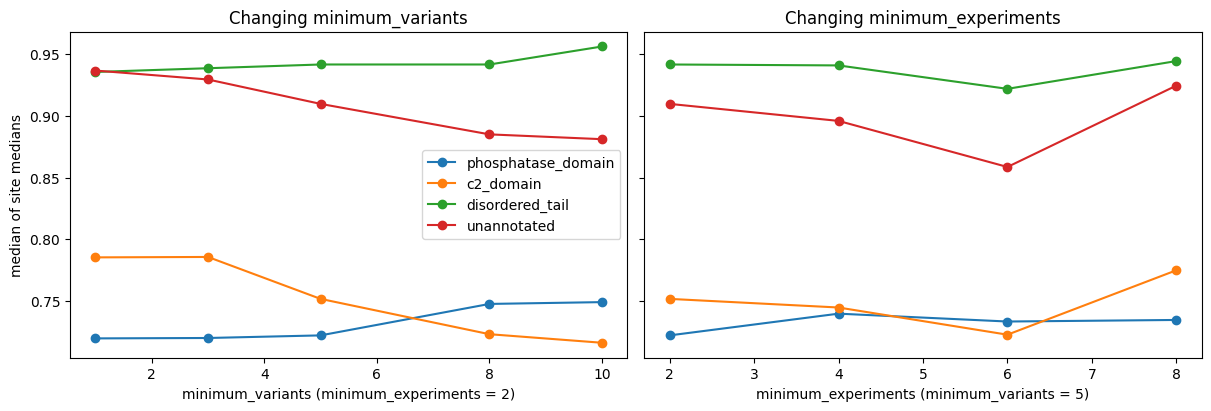

In [8]:
# plot: site median per region as the filters get stricter
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, layout="constrained")
for r in region_order:
    a = sens[(sens["region"] == r) & (sens["minimum_experiments"] == 2)]
    axes[0].plot(a["minimum_variants"], a["site_median"], marker="o", label=r)
    b = sens[(sens["region"] == r) & (sens["minimum_variants"] == 5)]
    axes[1].plot(b["minimum_experiments"], b["site_median"], marker="o", label=r)
axes[0].set(xlabel="minimum_variants (minimum_experiments = 2)", ylabel="median of site medians", title="Changing minimum_variants")
axes[1].set(xlabel="minimum_experiments (minimum_variants = 5)", title="Changing minimum_experiments")
axes[0].legend()
plt.show()